In [162]:
import os, sys
if '..' not in sys.path:
    sys.path.append('..')
    os.chdir('..')

import pandas as pd
import torch
import numpy as np

import src.inference as inf
from src.el_nino import read_enso_data

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
import plotly.graph_objects as go

In [163]:
VALIDATION = True
directory = 'checkpoint/msn-complete-br-data' 
config_file = "params-temperature-exp-2-c30.yaml"
read_path="results/temperature/last_model/"

params, dataset = inf.read_data(directory,config_file,validation=VALIDATION)

E, F = inf.get_model_results(read_path)

if VALIDATION:
    E_val, F_val = inf.get_model_results(read_path, validation=True)

tsne_E, tsne_prot, tsne_Eval = inf.get_TSNE(read_path, validation=VALIDATION)


INFO:root:data loader created
Loaded E and F from results/temperature/last_model/
Loaded E and F from results/temperature/last_model/


In [164]:
cluster_prob, cluster_id = torch.max(F, dim=1) 
df = pd.DataFrame({"cluster_id": cluster_id.cpu(), "cluster_prob": cluster_prob.cpu(),
                   'sample_type':'train','date':dataset.time})

if VALIDATION:

    val_cluster_prob, val_cluster_id = torch.max(F_val, dim=1) # Obtém os valores máximos e seus índices
    df_val = pd.DataFrame({"cluster_id": val_cluster_id.cpu(),"cluster_prob": val_cluster_prob.cpu(),
                           'sample_type':'val','date':dataset.val_time})
        
    df =  pd.concat([df,df_val]).reset_index(drop=True) 
    df = df.sort_values('date')
    
    combined_dataset = torch.cat((dataset[:][0], dataset.validation_imgs))[df.index]
    tsne = np.concatenate((tsne_E, tsne_Eval))[df.index]

    df = df.reset_index(drop=True)  

else:
    combined_dataset = dataset[:][0]

In [165]:
oni_index = read_enso_data()

In [166]:
df_el_nino = df.copy()
df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
df_el_nino = df_el_nino.merge(oni_index, left_on='date_period', right_index=True, how='left')

In [167]:
# # # Plot the TSNE results
# plt.figure(figsize=(10, 10))

# cluster_labels = F.argmax(axis=1).cpu().numpy()
# plt.scatter(tsne_E[:,0], tsne_E[:,1], c= df_el_nino[df_el_nino['sample_type']=='train']['label_color'].values, cmap='coolwarm',  s=0.2,alpha=1)
# plt.scatter(tsne_Eval[:,0], tsne_Eval[:,1], c= df_el_nino[df_el_nino['sample_type']=='val']['label_color'].values, cmap='coolwarm', s=0.2,alpha=1)

# for i, (x, y) in enumerate(tsne_prot):
#     plt.text(x, y, i, color='black', fontsize=12, ha='center', va='center')

# plt.title("t-SNE of Latent Points and Prototypes")
# plt.show()

"9.147772% dos dias do El Niño estão no Cluster 22"

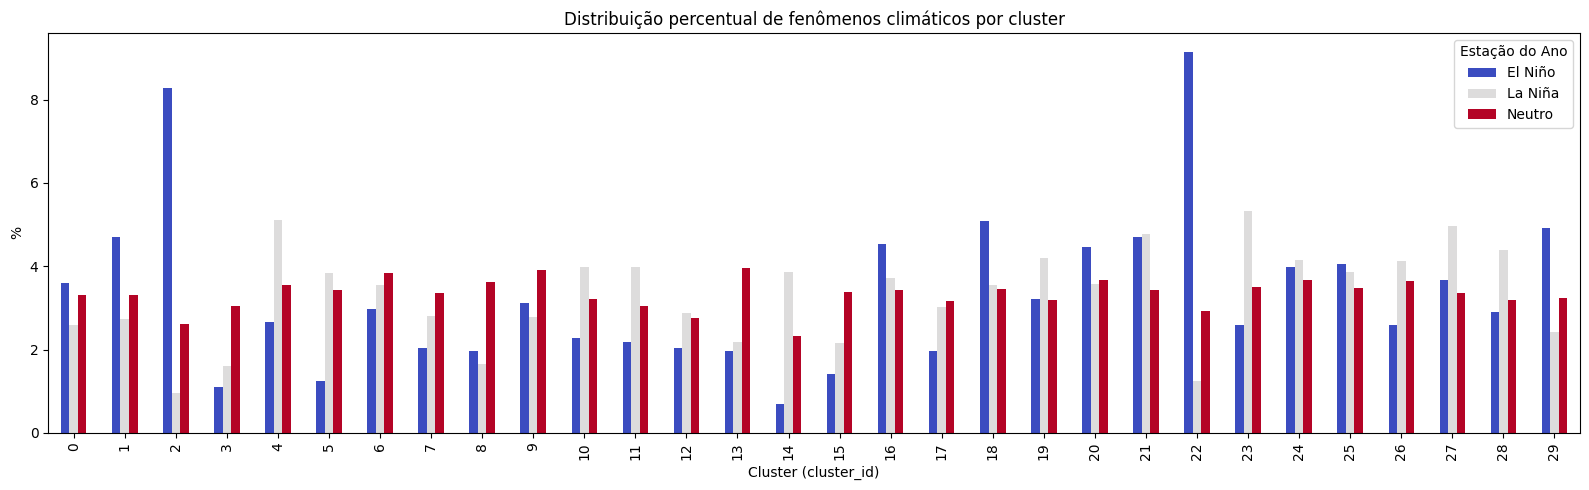

In [168]:
contagem = df_el_nino.groupby(['Label','cluster_id']).size().unstack()
contagem['total de dias'] = contagem.sum(axis=1)

percent = pd.DataFrame(index=contagem.index, columns=contagem.columns[:-1])
for col in percent.columns:
    percent[col] =  contagem[col]/contagem['total de dias'] * 100

percent.T.plot(kind='bar', stacked=False, figsize=(16, 5), colormap='coolwarm')
plt.title('Distribuição percentual de fenômenos climáticos por cluster')
plt.xlabel('Cluster (cluster_id)')
plt.ylabel('%')
plt.legend(title='Estação do Ano')
plt.tight_layout()
plt.show()

16.525424% dos pontos do Cluster 22 foram durante o El Niño

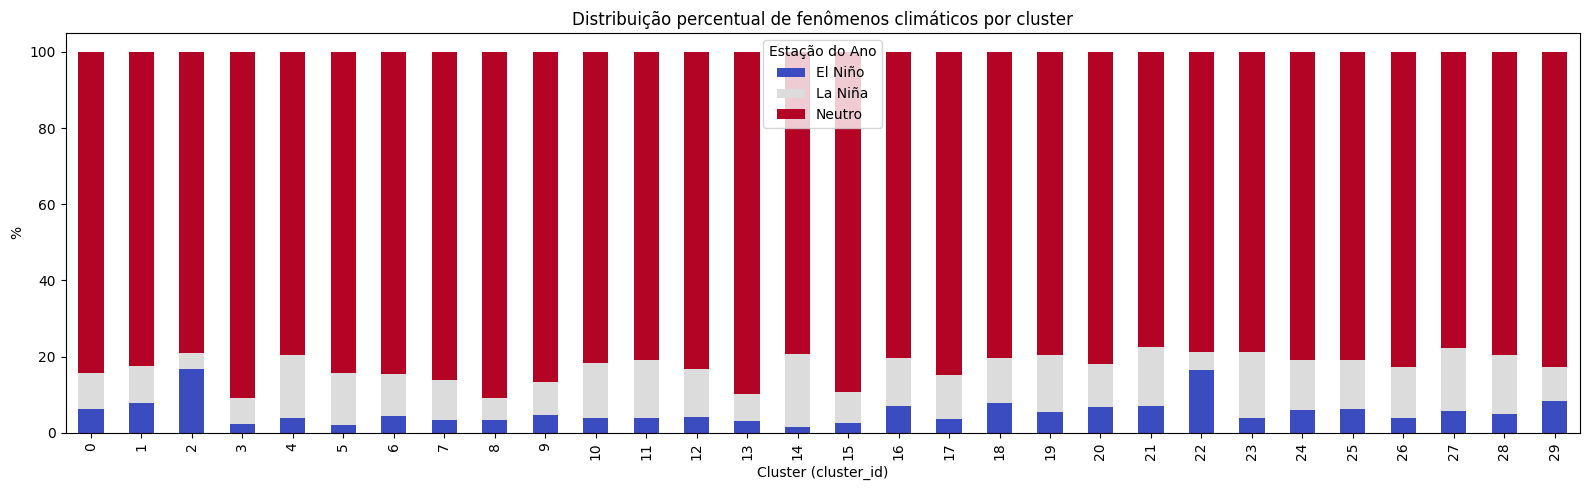

In [169]:
climatologia = pd.DataFrame(index=contagem.index, columns=contagem.columns[:-1])
climatologia.loc['climatologia'] =  contagem.sum(axis=0)

for col in climatologia.columns:
    climatologia.loc[contagem.index,col] =  contagem[col]/climatologia.loc['climatologia',col] * 100
climatologia

climatologia.drop("climatologia").T.plot(kind='bar', stacked=True, figsize=(16, 5), colormap='coolwarm')
plt.title('Distribuição percentual de fenômenos climáticos por cluster')
plt.xlabel('Cluster (cluster_id)')
plt.ylabel('%')
plt.legend(title='Estação do Ano')
plt.tight_layout()
plt.show()

Análise de Anomalia

Text(0.5, 1.0, 'Probabilidade de ocorrência de cada cluster')

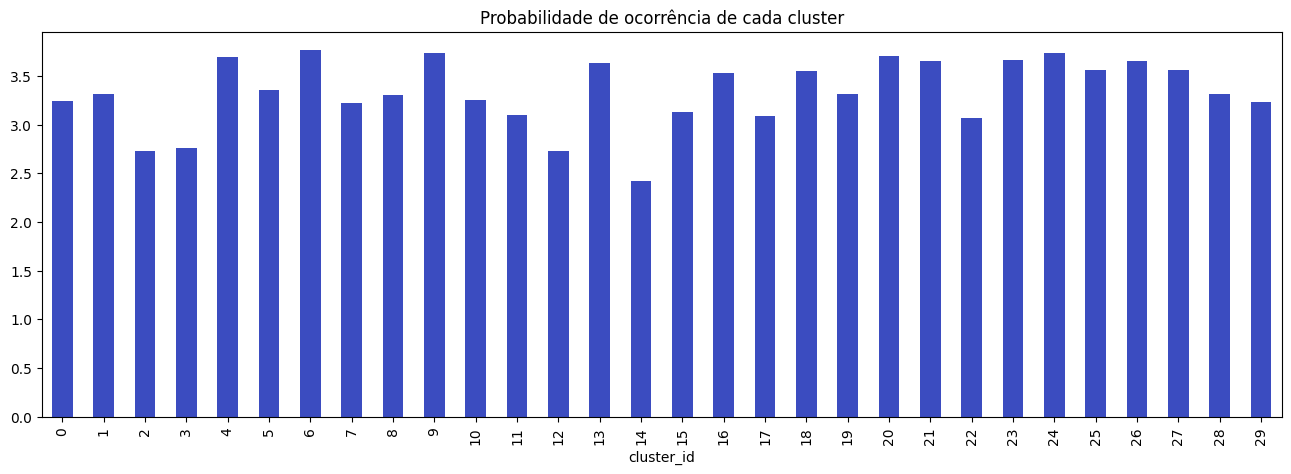

In [170]:
probablidade_cluster = climatologia.loc['climatologia']/climatologia.loc['climatologia'].sum()*100

probablidade_cluster.plot(kind='bar',figsize=(16, 5), colormap='coolwarm')
plt.title('Probabilidade de ocorrência de cada cluster')

Probailidades condicionais al El Niño:

Text(0.5, 1.0, 'Probabilidade de ocorrência de cada cluster')

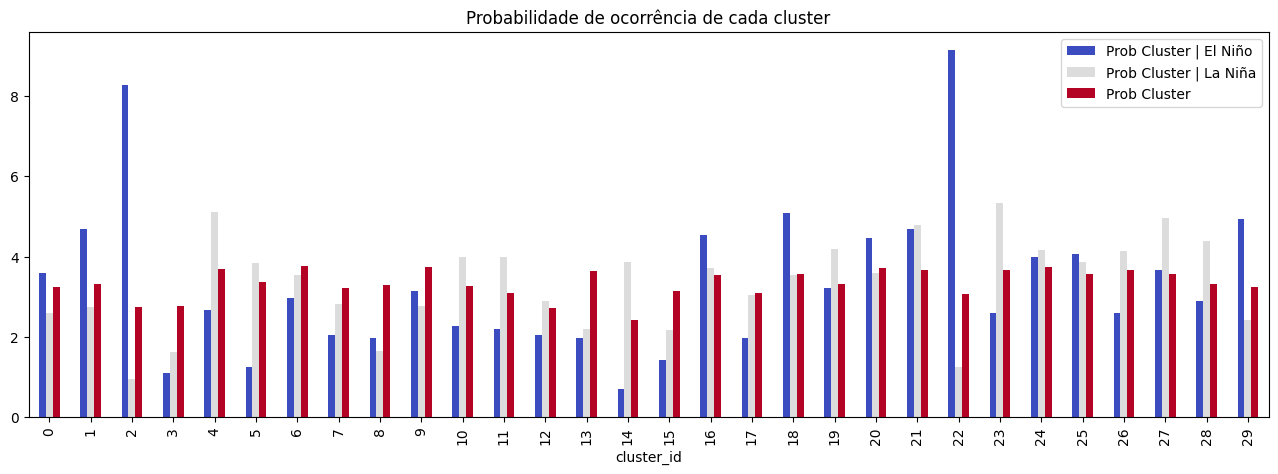

In [171]:
probablidade_cluster = climatologia.loc['climatologia']/climatologia.loc['climatologia'].sum()*100
probabilidades = probablidade_cluster.to_frame('Prob Cluster').join(percent.loc['El Niño'].to_frame('Prob Cluster | El Niño'))
probabilidades = probabilidades.join(percent.loc['La Niña'].to_frame('Prob Cluster | La Niña'))

probabilidades[['Prob Cluster | El Niño','Prob Cluster | La Niña','Prob Cluster',]].plot(kind='bar',figsize=(16, 5), colormap='coolwarm')
plt.title('Probabilidade de ocorrência de cada cluster')

Text(0.5, 1.0, 'Anomalia de Probabilidade de ocorrência de cada cluster')

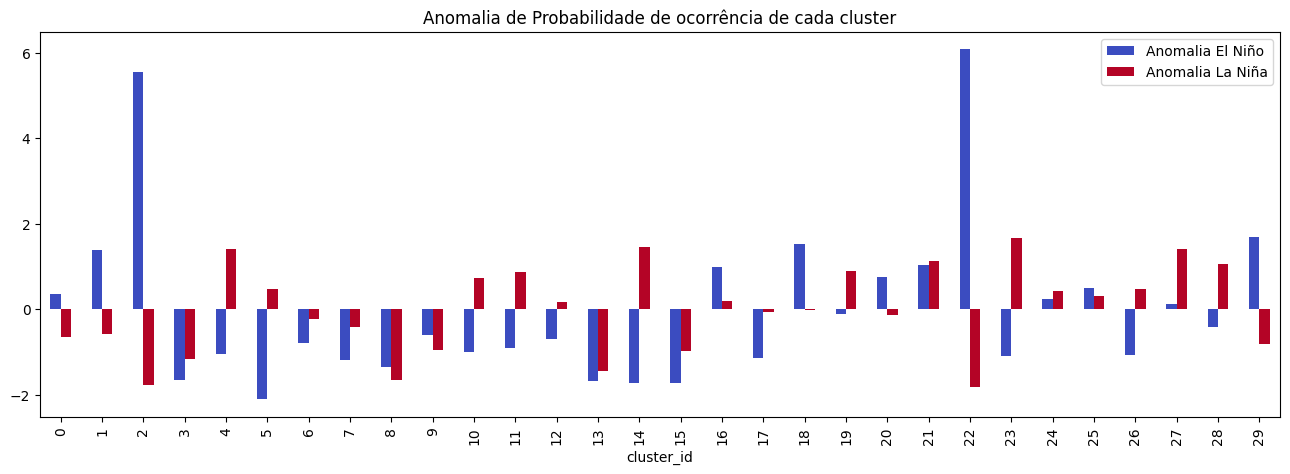

In [172]:
probabilidades['Anomalia El Niño'] = probabilidades['Prob Cluster | El Niño'] - probabilidades['Prob Cluster']
probabilidades['Anomalia La Niña'] = probabilidades['Prob Cluster | La Niña'] - probabilidades['Prob Cluster']
probabilidades[['Anomalia El Niño','Anomalia La Niña']].plot(kind='bar',figsize=(16, 5), colormap='coolwarm')
plt.title('Anomalia de Probabilidade de ocorrência de cada cluster')

In [173]:
# import plotly.graph_objects as go
# df = df_el_nino.groupby(['date_period','cluster_id']).size().unstack().fillna(0)[[22]].join(oni_index[['ONI','Label']])
# df.index = df.index.to_timestamp()
# # df =  df[df.index.year>=1990]

# label_colors = {
#     'El Niño': 'rgba(255,0,0,0.2)',    # vermelho claro
#     'La Niña': 'rgba(0,0,255,0.2)',    # azul claro
#     'Neutro': 'rgba(128,128,128,0.2)' # cinza claro
# }

# fig = go.Figure()



# fig.add_trace(go.Bar(
#     x=df.index,
#     y=df['ONI'],
#     name='ONI',
#     marker_color='red',
#     yaxis='y2',
#     text=df['Label'],
#     hovertemplate='Data: %{x}<br>ONI: %{y}<br>Label: %{text}<extra></extra>'
# ))


# fig.add_trace(go.Scatter(
#     x=df.index,
#     y=df[22],
#     name='Coluna 22',
#     marker_color='darkblue',
#     marker=dict(size=10),
#     mode='lines',
#     yaxis='y1',
#     hovertemplate='Data: %{x}<br>22: %{y}<br>Label: %{text}<extra></extra>'
# ))


# for i in range(len(df)):
#     fig.add_shape(
#         type="rect",
#         x0=df.index[i],
#         x1=df.index[i] + pd.offsets.MonthEnd(0),  # final do mês
#         y0=0, y1=1,  # preencher verticalmente
#         xref='x',
#         yref='paper',  # coordenadas do gráfico (0-1)
#         fillcolor=label_colors[df['Label'][i]],
#         line=dict(width=0),
#         layer='below'
#     )

# fig.update_layout(
#     title='Coluna 22 (barras) e ONI (linha) com períodos destacados',
#     xaxis=dict(title='Data'),
#     yaxis=dict(title='Coluna 22', side='left', showgrid=False),
#     yaxis2=dict(title='ONI', side='right', overlaying='y'),
#     legend=dict(x=0.01, y=0.99),
#     bargap=0.2,
#     template='plotly_white'
# )

# fig.show()

> Encontrar um lag ótimo (quanto tempo depois o el nino afeta as distribuições desse local?)

> Validar com um teste estatístico

> Repetir só com os níveis de SST

> Repetir com modelo com mais dados (adicionar prep, etc?)

Anomalias de probabilidade vs lags:

In [174]:
anom = []
for lag in range(0,13):
    df_el_nino = df.copy()
    df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
    df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')

    contagem = df_el_nino.groupby(['Label','cluster_id']).size().unstack()
    contagem['total de dias'] = contagem.sum(axis=1)

    percent = pd.DataFrame(index=contagem.index, columns=contagem.columns[:-1])
    for col in percent.columns:
        percent[col] =  contagem[col]/contagem['total de dias'] * 100

    climatologia = pd.DataFrame(index=contagem.index, columns=contagem.columns[:-1])
    climatologia.loc['climatologia'] =  contagem.sum(axis=0)

    for col in climatologia.columns:
        climatologia.loc[contagem.index,col] =  contagem[col]/climatologia.loc['climatologia',col] * 100

    probablidade_cluster = climatologia.loc['climatologia']/climatologia.loc['climatologia'].sum()*100
    probablidade_cluster = climatologia.loc['climatologia']/climatologia.loc['climatologia'].sum()*100
    probabilidades = probablidade_cluster.to_frame('Prob Cluster').join(percent.loc['El Niño'].to_frame('Prob Cluster | El Niño'))
    probabilidades = probabilidades.join(percent.loc['La Niña'].to_frame('Prob Cluster | La Niña'))

    probabilidades['Anomalia El Niño'] = probabilidades['Prob Cluster | El Niño'] - probabilidades['Prob Cluster']
    probabilidades['Anomalia La Niña'] = probabilidades['Prob Cluster | La Niña'] - probabilidades['Prob Cluster']

    cur_anomalias = probabilidades['Anomalia El Niño'].to_frame(lag)
    anom.append(cur_anomalias)
anom = pd.concat(anom,axis=1)

array([[<Axes: title={'center': '0'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '1'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '2'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '3'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '4'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '5'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>],
       [<Axes: title={'center': '6'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '7'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '8'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '9'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '10'}, xlabel='Lag (months)', ylabel='Anomaly (%)'>,
        <Axes: title={'center': '11'}, xlabel='Lag (months)', ylabel='Anom

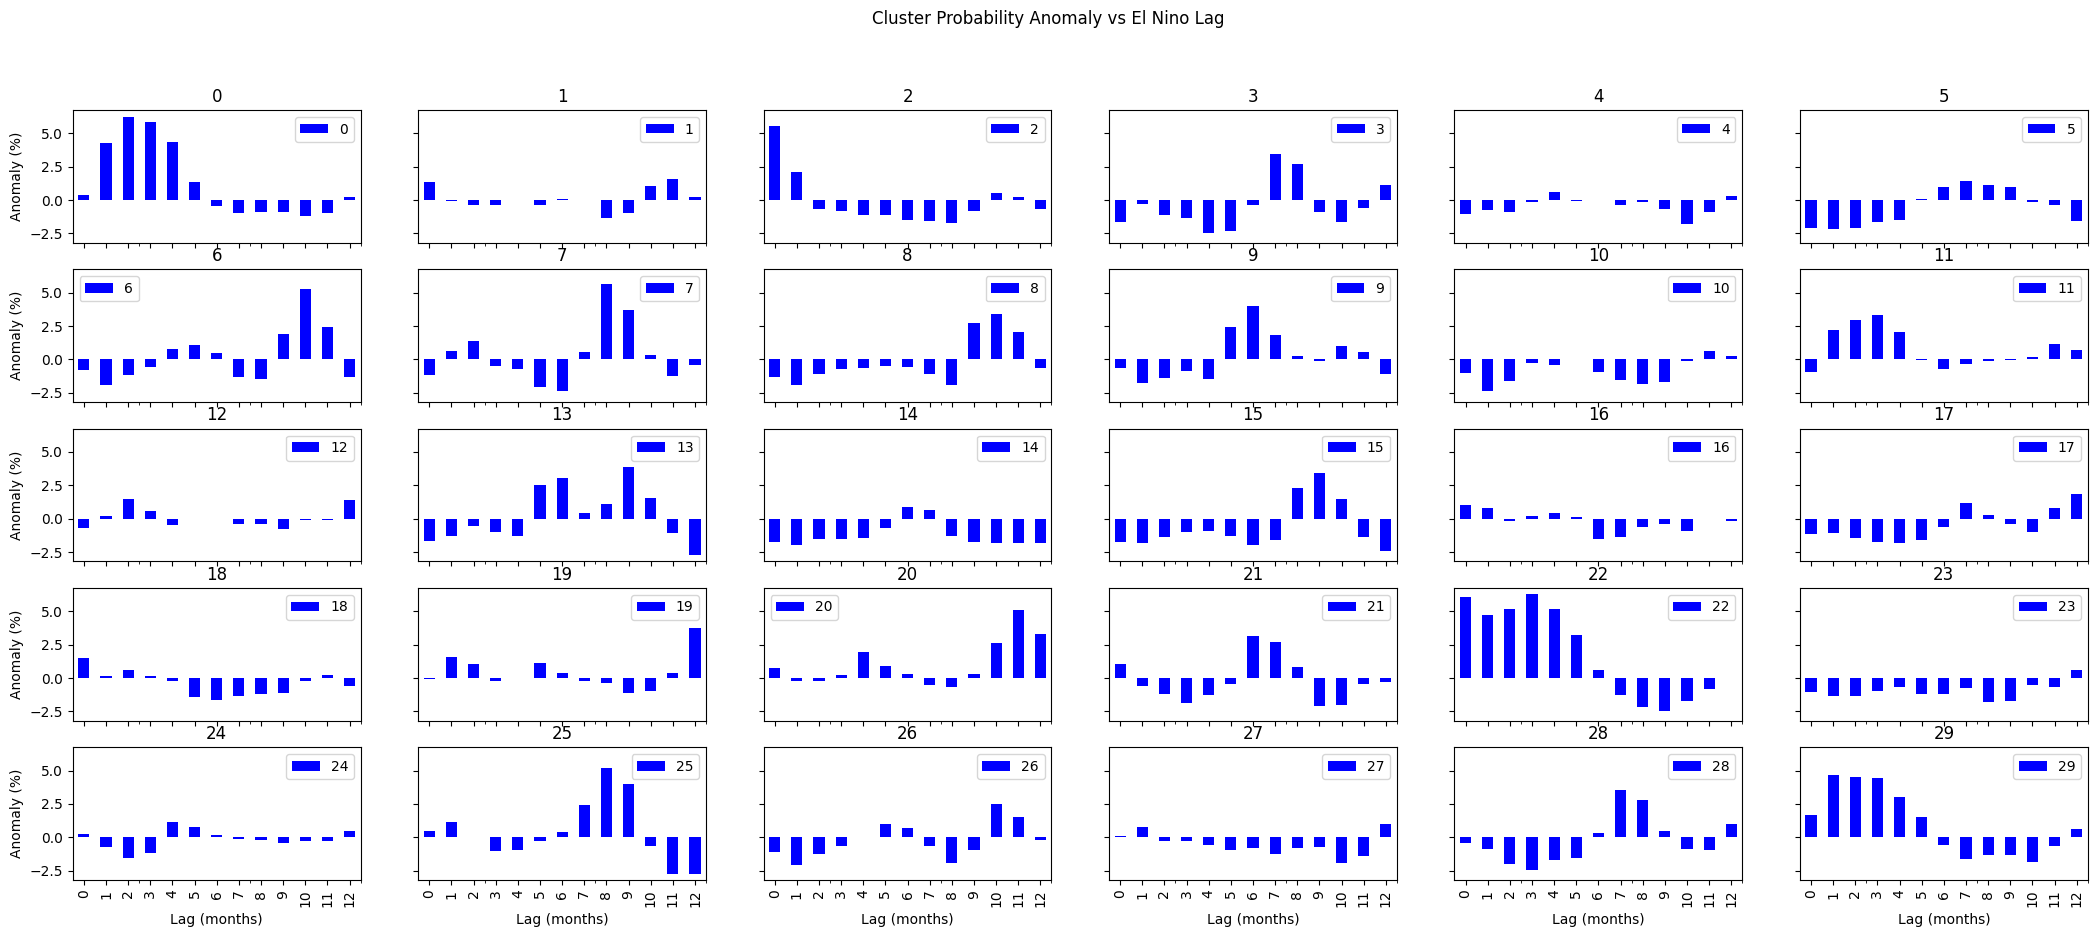

In [175]:
anom.T.plot.bar(
    subplots=True,
    layout=(5, 6),
    figsize=(26, 10),
    color='blue',
    # colormap='coolwarm',
    sharex=True,
    sharey=True,
    title='Cluster Probability Anomaly vs El Nino Lag',
    ylabel='Anomaly (%)',
    xlabel='Lag (months)'

)

<Axes: title={'center': 'Cluster 22 Monthly Frequency vs ONI'}, xlabel='Count', ylabel='ONI'>

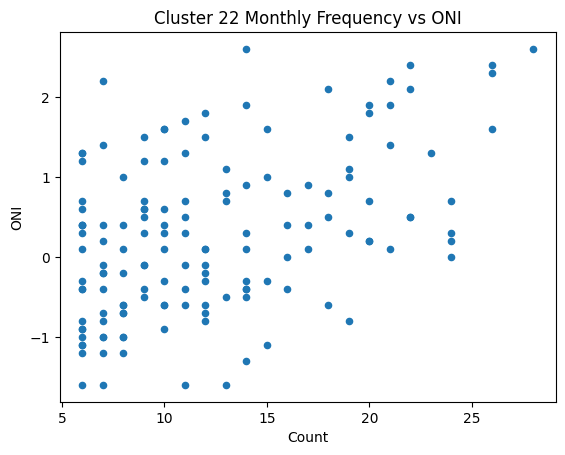

In [176]:
lag = 3
df_el_nino = df.copy()
df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
freq = df_el_nino[df_el_nino['cluster_id'].isin([29,22,0])].groupby('date_period').agg({'ONI':'mean','cluster_id':'size'}).rename({"cluster_id":"Count"},axis=1)
freq[freq['Count']>5].plot.scatter(y='ONI',x='Count',title='Cluster 22 Monthly Frequency vs ONI')